# Jordan Titanic Data Features
**Author:** Jordan  
**Date:** November 11, 2025 <br>
**Objective:** Data inspection, exploration, and evaluation of Decision Tree and Random Forest classification models.


## Introduction
This project uses the Mushroom dataset to evalutate and compare Decision Tree and Random Forest models.  The mushroom dataset contains 8,124 samples of mushrooms with 23 different features.  First, we will inspect, explore and clean our data.  Then, we will train and evaluate Decision Tree and Random Forest models predicting edibility of the mushrooms.

## Imports
First, we import the necessary Python libraries for our analysis. 

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.tree import DecisionTreeClassifier, plot_tree

from stats_jordan import classification_table


## Section 1. Load and Inspect the Data

### 1.1 Load the Dataset
Next, we load the Mushroom dataset and view its head.

In [52]:
pd.set_option("display.max_columns", 25)
# Load the mushroom dataset
mushroom_df: pd.DataFrame = pd.read_csv("../../data/agaricus-lepiota.data", header=None, na_values="?")
mushroom_df.columns = [
    "poisonous", "cap-shape", "cap-surface", "cap-color", "bruises?", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color", "stalk-shape",
    "stalk-root", "stalk-surface-above-ring", "stalk-surface-below-ring",
    "stalk-color-above-ring", "stalk-color-below-ring", "veil-type", "veil-color",
    "ring-number", "ring-type", "spore-print-color", "population", "habitat"
]
# Display the first 10 rows of the dataset
mushroom_df.head(10)

,poisonous,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g
5,e,x,y,y,t,a,f,c,b,n,e,c,s,s,w,w,p,w,o,p,k,n,g
6,e,b,s,w,t,a,f,c,b,g,e,c,s,s,w,w,p,w,o,p,k,n,m
7,e,b,y,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,s,m
8,p,x,y,w,t,p,f,c,n,p,e,e,s,s,w,w,p,w,o,p,k,v,g
9,e,b,s,y,t,a,f,c,b,g,e,c,s,s,w,w,p,w,o,p,k,s,m


### 1.2 Preliminary Inspection

Then, we check for missing values and display summary statistics.

In [53]:
# Check data types and missing values
mushroom_df.info()
# Summary statistics
display(mushroom_df.describe())
# Check for missing values
display(mushroom_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   poisonous                 8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises?                  8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                5644 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

,poisonous,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,5644,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,2,4,4,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,t,b,s,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,4608,3776,5176,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


poisonous                      0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises?                       0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64

### Reflection 1:

1) What do you notice about the dataset? 

    The dataset has 8,124 observations of 23 total categorical features.
2) Are there any data issues?
   
   The 'stalk-root' feature has 2480 missing entries.  All other features contain no missing entries.

## Section 2. Data Exploration and Preparation

Now, we will explore our dataset with charts.  Depending on what we learn, cleaning and/or feature engineering may be in order.

### 2.1 Count Plots

Since all of our features are categorical, we create count plots of each feature.

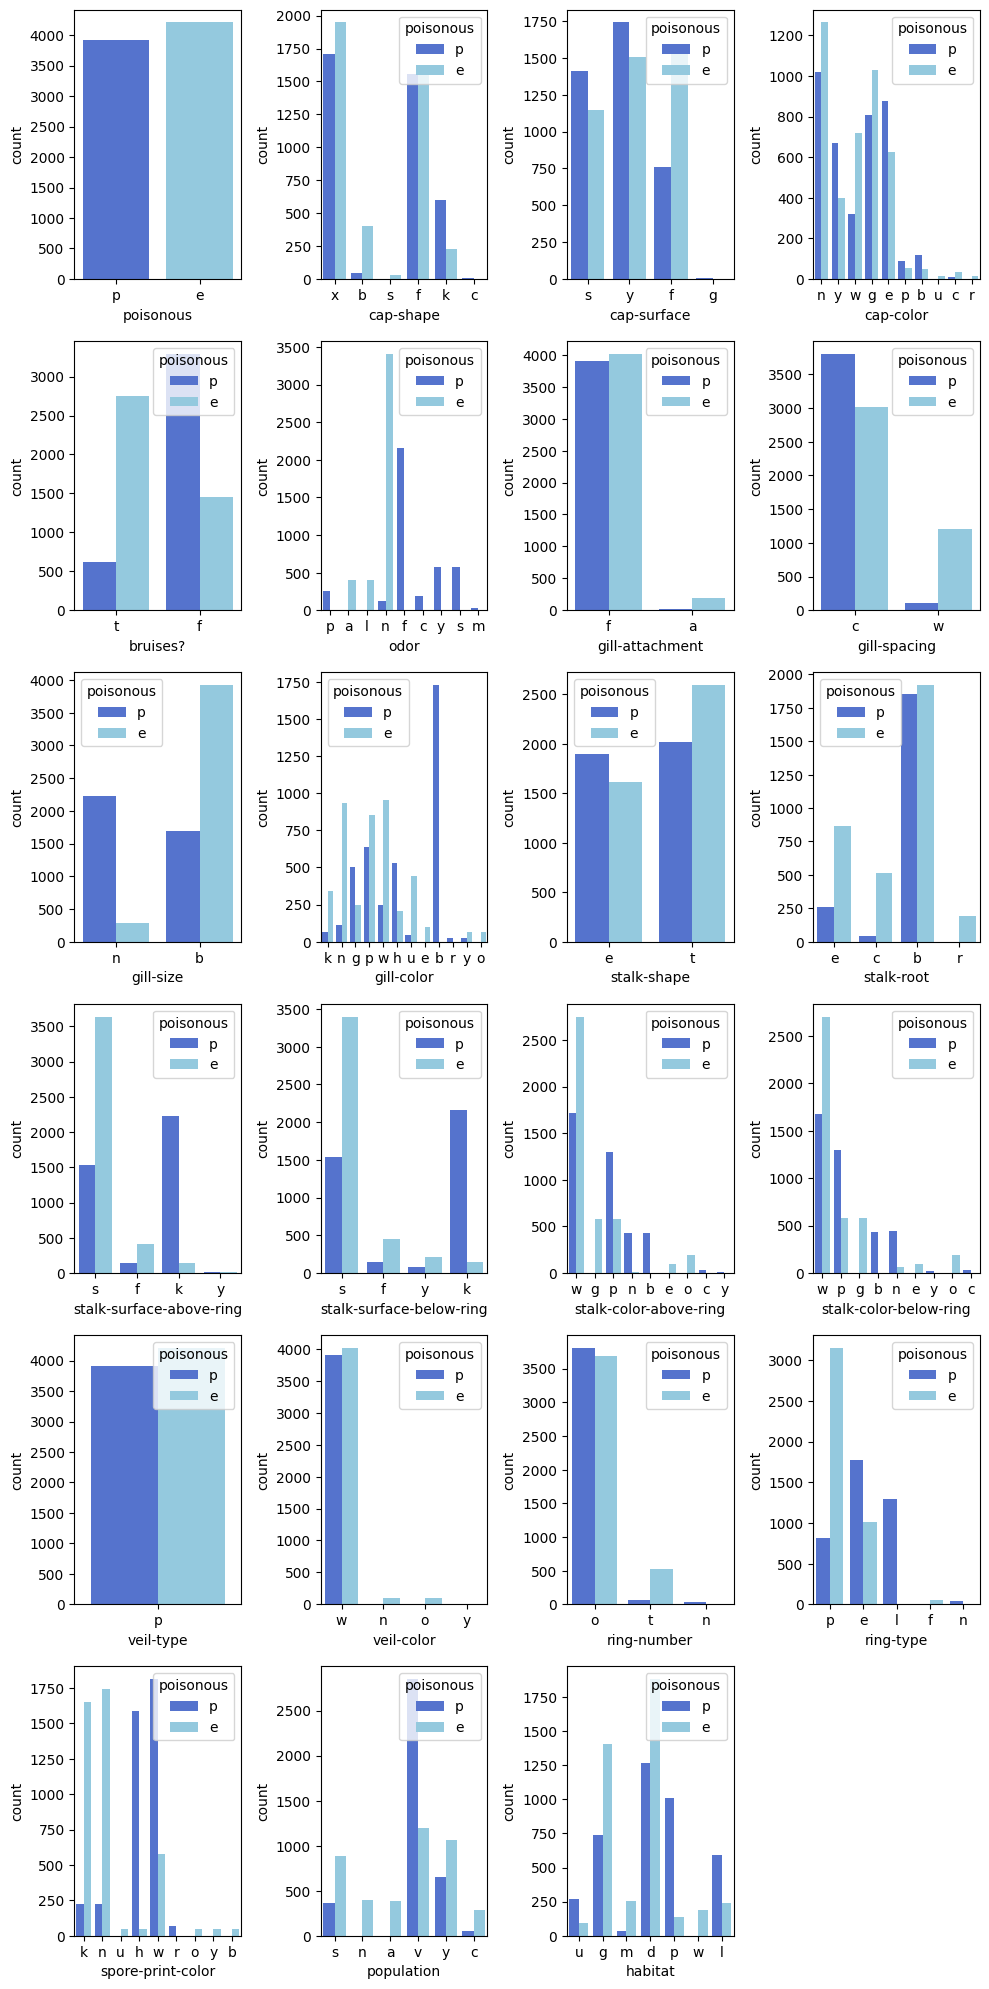

In [54]:
# Plot countplots for all categorical features
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(10,20))
axes = axes.flatten()

for idx, col in enumerate(mushroom_df.columns):

    sns.countplot(x=col, hue="poisonous", data=mushroom_df, ax=axes[idx], palette=["royalblue","skyblue"])

axes[-1].set_axis_off()
plt.tight_layout()
plt.show()

Noticing that classes within the features of 'odor', 'gill-size', and 'spore-print-color' all respond to edibility, we take a closer look at these features.

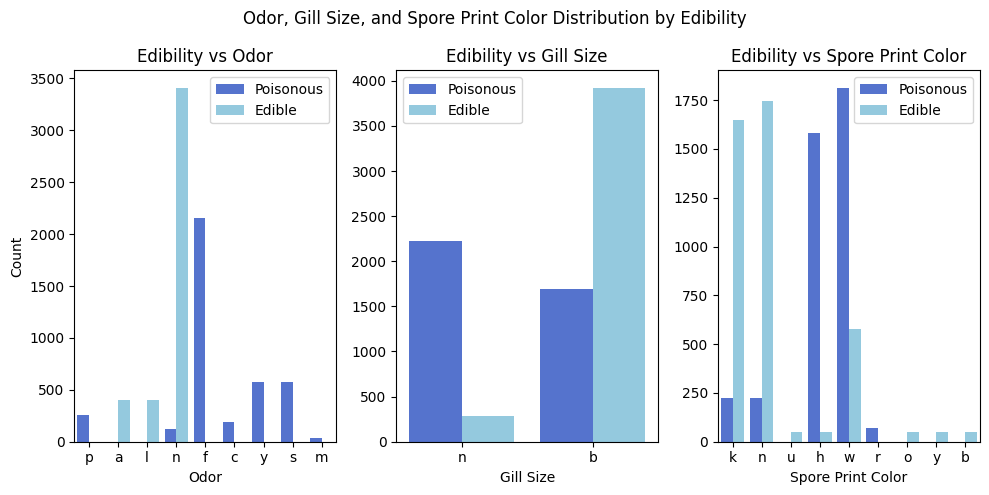

In [55]:
# Plot countplots of 'odor', 'gill-size', and 'spor-print-color'
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10,5))

for ax, col in zip(axes.flatten(), ("odor", "gill-size", "spore-print-color"), strict=True):

    sns.countplot(x=col, hue="poisonous", data=mushroom_df, ax=ax, palette=["royalblue","skyblue"])
    ax.set_title(f"Edibility vs {col.replace("-", " ").title()}")
    ax.set_ylabel("Count") if ax is axes[0] else ax.set_ylabel("")
    ax.set_xlabel(col.replace("-", " ").title())
    ax.legend(handles=ax.get_legend_handles_labels()[0], labels=["Poisonous", "Edible"])

fig.suptitle("Odor, Gill Size, and Spore Print Color Distribution by Edibility")
plt.tight_layout()
plt.show()

### 2.2 Clean Data and Feature Selection

To better understand our models later on, we encode each class within 'odor', 'spore-print-color', and 'gill-size' with its full class name.  Then, we one-hot encode the three features for optimal performance of our Decision Tree and Random Forest models.

In [ ]:
# Declare dictionary of full class names for each class
class_names: dict = {
    "odor": {"a": "almond", "l": "anise", "c": "creosote", "y": "fishy", "f": "foul",
             "m": "musty", "n": "none", "p": "pungent", "s": "spicy"},
    "spore-print-color": {"k": "black", "n": "brown", "b": "buff", "h": "chocolate", "r": "green",
                          "o": "orange", "u": "purple", "w": "white", "y": "yellow"},
    "gill-size": {"b": "broad", "n": "narrow"}
}

features_pred: list = ["odor", "spore-print-color", "gill-size"]
# Encode classes of each feature and one-hot encode each feature
X_encoded = pd.get_dummies(mushroom_df[features_pred].replace(class_names), columns = features_pred)
# Numericaly encode target feature
y_encoded = mushroom_df["poisonous"].map({"p": 1, "e": 0})


### Reflection 2:

1) What patterns or anomalies do you see? 

    We observed a strong predictive pattern in the countplots of 'odor', 'gill-size', and 'spore-print-color' for edibility.  We also observed that our target feature, poisonous, is not significantly unbalanced.
2) Do any features stand out? 

    The features of 'odor', 'gill-size', and 'spore-print-color' stand out as predicting features for edibility as seen from the countplots.
3) What preprocessing steps were necessary to clean and improve the data? 

    Binary encoding was performed on the target feature, edibility, and one-hot encoding was performed on the predicting features to ensure ordering is not assumed in the classes of each feature for our models.
4) Did you create or modify any features to improve performance?
   
   One-hot encoding of the features was performed on 'odor', 'gill-size', and 'spore-print-color' to optimize model performance.



## Section 3. Choose Features and Target

With classification in mind, we now select input and target features for our models.


### 3.1 Choose Features and Target


dfdfd

### 3.2 Define X and y



In [57]:
X = X_encoded

y = y_encoded

Reflection 3:

1) Why did you choose these features?  
   We chose the predicting features of 'spore-print-color', 'odor', and 'gill-size' based on their response to our target feature, 'poisonous', in the countplots.
2) How might they impact predictions or accuracy?
   The predicting features 'spore-print-color', 'odor', and 'gill-size' will significantly impact prediction accuracy due to them being highly separable as observed in the count plots.  The models will be able to create clean decision boundaries with low Gini impurity.  

## Section 4. Train and Evaluate Decision Tree Model

We will now split the data into training and test sets using StratifiedShuffleSplit.  Then evaluation of the Decision Tree results will be performed.


### 4.1 Split the Data

First, we split our data into training and testing sets.

In [58]:
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)

for train_idx, test_idx in splitter.split(X, y):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

### 4.2 Train Decision Tree Models

Now, we train our Decision Tree models for each case.

In [59]:
tree_model = DecisionTreeClassifier(random_state=123)
tree_model.fit(X_train, y_train);

### 4.3 Evaluate Performance

Now, we compare performance metrics of the training and testing sets to check for overfitting and underfitting.

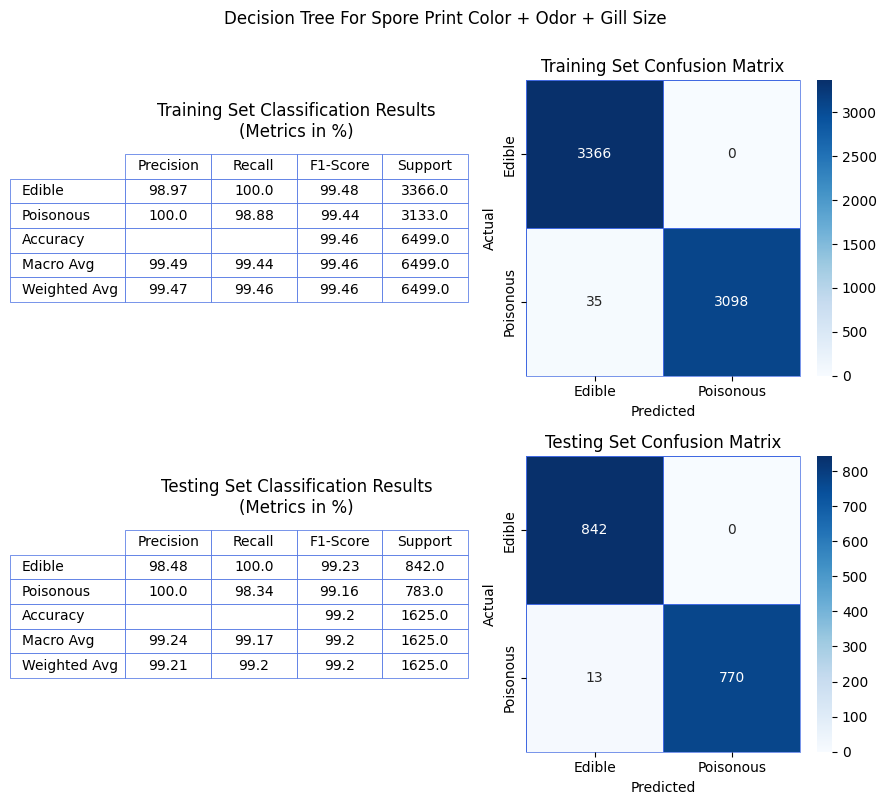

In [60]:
fig, axes = plt.subplots(nrows= 2, ncols= 2, figsize=(9, 8))

for idx, (X_tt, y_tt) in enumerate(((X_train, y_train), (X_test, y_test))):

    y_pred = tree_model.predict(X_tt)
    title_tt: str = "Training" if idx == 0 else "Testing"

    classification_table(y_tt, y_pred, axes[idx,0], target_names=["Edible", "Poisonous"])
    axes[idx,0].set_title(f"{title_tt} Set Classification Results\n(Metrics in %)", y=0.78)

    cm_nn3 = confusion_matrix(y_tt, y_pred)
    sns.heatmap(cm_nn3, annot=True, cmap="Blues", ax=axes[idx,1],
                linewidths=.5, linecolor="royalblue", fmt="d")
    axes[idx,1].patch.set_edgecolor("royalblue")
    axes[idx,1].patch.set_linewidth(0.5)
    axes[idx,1].set(xlabel="Predicted", ylabel="Actual", title=f"{title_tt} Set Confusion Matrix")
    axes[idx,1].set_xticklabels(["Edible", "Poisonous"])
    axes[idx,1].set_yticklabels(["Edible", "Poisonous"])

fig.suptitle("Decision Tree For Spore Print Color + Odor + Gill Size", y=1)
plt.tight_layout()
plt.show()
fig.savefig("tree_classification.png", bbox_inches="tight")

The performance metrics are nearly identical for the testing and training sets, thus our models are not over or underfitting.

Finally, we plot our decision tree model to visualize the decision rules and structure learned by our model.

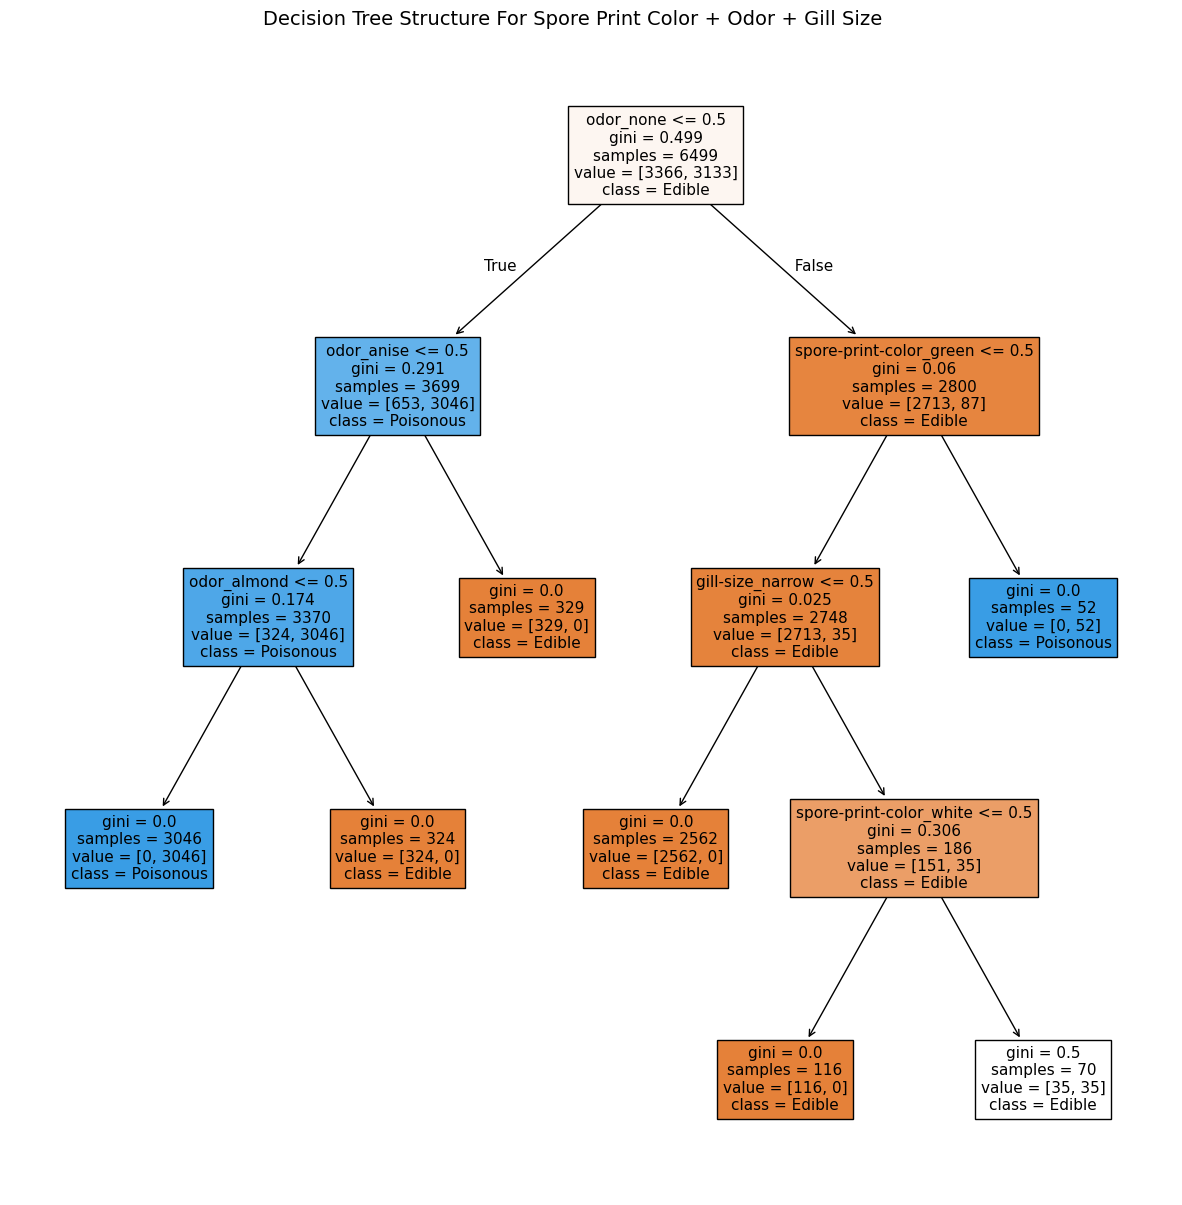

In [61]:
fig = plt.figure(figsize=(15,15))

plot_tree(tree_model,
          feature_names=X_train.columns.tolist(),
          class_names=["Edible", "Poisonous"],
          filled=True,
          fontsize=11
    )

fig.suptitle("Decision Tree Structure For Spore Print Color + Odor + Gill Size", size=14, y=.9)
plt.show()
fig.savefig("tree_plot.png", bbox_inches="tight")

### Reflection 4

1) How well did the model perform?

    With all performance metrics above 98%, the Decision Tree model performed exceptionally well.  The model is highly effective at correctly classifying mushroom edibility based on 'spore-print-color', 'odor', and 'gill-size'.
2) Any surprises in the results?

    A high performing model was expected due to the correlation between the input features and target feature seen in the count plots.  However, the model achieved 100% precision for the poisonous class and 100% recall for the edible class, resulting in perfect classification across the test set.

## Section 5. Train and Evaluate Random Forest Model



### 5.1 Train and Evaluate Random Forest Model

We now train and evaluate our Random Forest Model for 'spore-print-color', 'odor', and 'gill-size'.

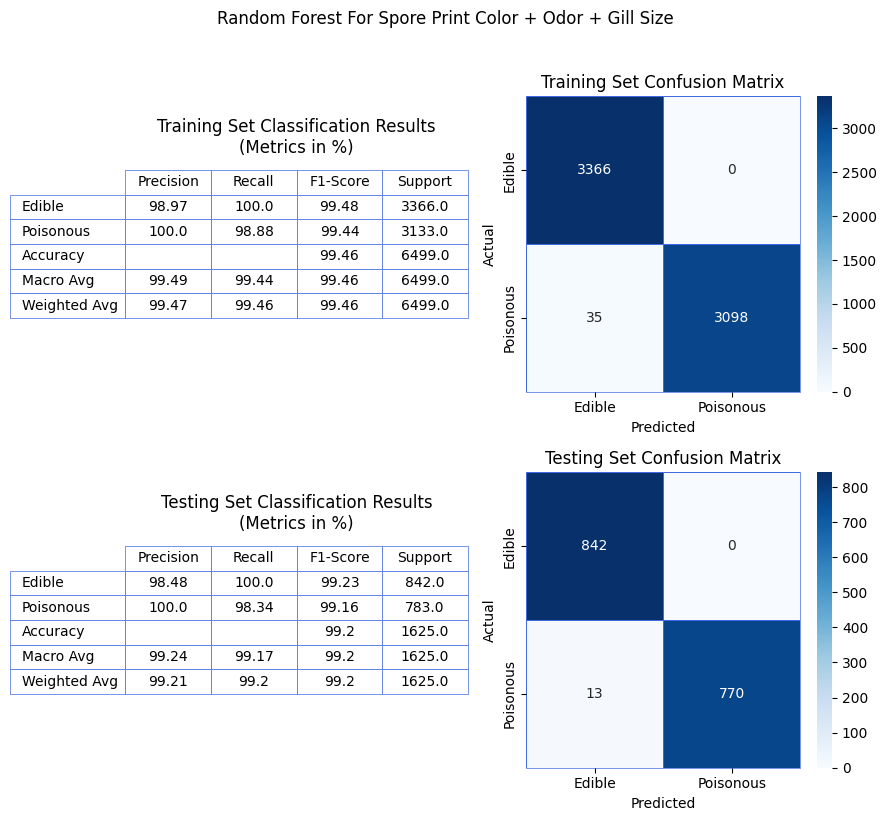

In [62]:
rf_model = RandomForestClassifier(random_state=123)
rf_model.fit(X_train, y_train)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(9, 8))

for idx, (X_tt, y_tt) in enumerate(((X_train, y_train), (X_test, y_test))):

    y_pred = rf_model.predict(X_tt)
    title_tt: str = "Training" if idx == 0 else "Testing"

    classification_table(y_tt, y_pred, axes[idx,0], target_names=["Edible", "Poisonous"])
    axes[idx,0].set_title(f"{title_tt} Set Classification Results\n(Metrics in %)", y=0.78)

    cm = confusion_matrix(y_tt, y_pred)
    sns.heatmap(cm, annot=True, cmap="Blues", ax=axes[idx,1],
                linewidths=.5, linecolor="royalblue", fmt="d")
    axes[idx,1].patch.set_edgecolor("royalblue")
    axes[idx,1].patch.set_linewidth(0.5)
    axes[idx,1].set(xlabel="Predicted", ylabel="Actual", title=f"{title_tt} Set Confusion Matrix")
    axes[idx,1].set_xticklabels(["Edible", "Poisonous"])
    axes[idx,1].set_yticklabels(["Edible", "Poisonous"])

fig.suptitle("Random Forest For Spore Print Color + Odor + Gill Size", y=1.02)
plt.tight_layout()
plt.show()
fig.savefig("rf_classification.png", bbox_inches="tight")

The performance metrics are nearly identical for the testing and training sets, thus our models are not over or underfitting.

### 5.2 Compare Performance of All Models

Inspection of the performance metrics for the Decision Tree and Random Forest models reveals that both models performed identicaly.  This indicates that for this specific dataset, both algorithms successfully utilized the predicting features to achieve optimal classification.

### Reflection 5.

1) Which model performed better?

    In this case, both models performed identically.

2) Why might one classifier be more effective in this specific case?

    The Random Forest model might be a more effective classifier in this specific case since it mitigates the risk of overfitting with the ensemlble approach in contrast to a single Decision Tree.

In [64]:
mushroom_df["poisonous"].value_counts()

poisonous
e    4208
p    3916
Name: count, dtype: int64

## Section 6. Final Thoughts & Insights

### 6.1 Summarize Findings


| Model Type | Features Used | Accuracy | Precision | Recall | F1-Score |
|------------|---------------|----------|-----------|--------|-----------|
| Decision Tree | spore-print-color + odor + gill-size | 99.2% | 99.21% | 99.20% | 99.20% |
| Random Forest | spore-print-color + odor + gill-size | 99.2% | 99.21% | 99.20% | 99.20% |

(Weighted averages reported for performance metrics due to slight imbalance in classes of target feature (4208-3916))

### 6.2 Challenges Faced

I initially had trouble with the confusion matrix showing the larger values in scientific notation.  This was corrected by passing the fmt='d' parameter to sns.heatmap().

### 6.3 If you had more time, what would you try next?

With more time given, I would like to run several sets of input features that do not initially show as strong a correlation to the target feature to see if a reasonable model can still be constructed.

### Reflection 6.

1) What did you learn from this project?

    I learned that while Random Forests often achieve identical performance metrics to simple Decision Trees on clean data, they are generally preferred in real-world applications for their inherent robustness and ability to mitigate overfitting through their ensemble approach.